# M4.Ex2: Penguins Classification (PyCaret)

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M6/exercises/ex2_pycaret_classification.ipynb)

## Exercise

Your task is to follow the steps outlined here, and apply them on the **Palmer Penguins Dataset** below:

- [**🚀 Classification**](https://pycaret.gitbook.io/docs/get-started/quickstart#classification)
    - Setup
    - Compare Models
    - Analyze Model
    - Predictions
    - Save the model

## Palmer Penguins Dataset

The goal of palmer penguins is to provide a great dataset for data exploration & visualization, as an alternative to iris.

The data contains 344 penguins. There are 3 different species of penguins in this dataset, collected from 3 islands in the Palmer Archipelago, Antarctica.

- Features: `4` numerical, `2` categorical
- Target: `species` (Categorical / 3 classes)
- Size: `344` samples
- Source: [Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/)

### Load the data

In [14]:
!pip install pycaret

In [3]:
import seaborn as sns

penguins = sns.load_dataset('penguins')
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


## Experiments

1. **First experiment**:
    - X = Flipper Length (numerical) & Bill Length (numerical)
    - y = Species (categorical)
2. **Second experiment**:
    - X = Weights (numerical) & Species (categorical)
    - y = Sex (categroical)
3. **Third experiment**:
    - X = `island`, `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`
    - y = Sex and Species (multi-label classification)

In [4]:
from pycaret.classification import *
df = penguins [['bill_length_mm','bill_depth_mm','species']]
s = setup(df, target = 'species', session_id = 123)

,Description,Value
0,Session id,123
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(344, 3)"
5,Transformed data shape,"(344, 3)"
6,Transformed train set shape,"(240, 3)"
7,Transformed test set shape,"(104, 3)"
8,Numeric features,2
9,Rows with missing values,0.6%


In [5]:
best = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.9667,0.9994,0.9667,0.9724,0.9667,0.9478,0.9504,0.1580
knn,K Neighbors Classifier,0.9625,0.9920,0.9625,0.9665,0.9621,0.9407,0.9428,0.0500
rf,Random Forest Classifier,0.9583,0.9983,0.9583,0.9656,0.9586,0.9348,0.9378,0.1900
lda,Linear Discriminant Analysis,0.9583,0.0000,0.9583,0.9620,0.9575,0.9343,0.9366,0.0280
xgboost,Extreme Gradient Boosting,0.9583,0.9964,0.9583,0.9640,0.9576,0.9340,0.9368,0.0800
qda,Quadratic Discriminant Analysis,0.9542,0.0000,0.9542,0.9585,0.9534,0.9279,0.9304,0.0300
gbc,Gradient Boosting Classifier,0.9542,0.0000,0.9542,0.9598,0.9541,0.9278,0.9306,0.4760
lightgbm,Light Gradient Boosting Machine,0.9542,0.9949,0.9542,0.9622,0.9538,0.9280,0.9318,0.1530
lr,Logistic Regression,0.9500,0.0000,0.9500,0.9541,0.9486,0.9211,0.9239,1.1160
dt,Decision Tree Classifier,0.9375,0.9533,0.9375,0.9422,0.9375,0.9018,0.9041,0.0310


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [6]:
evaluate_model(best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

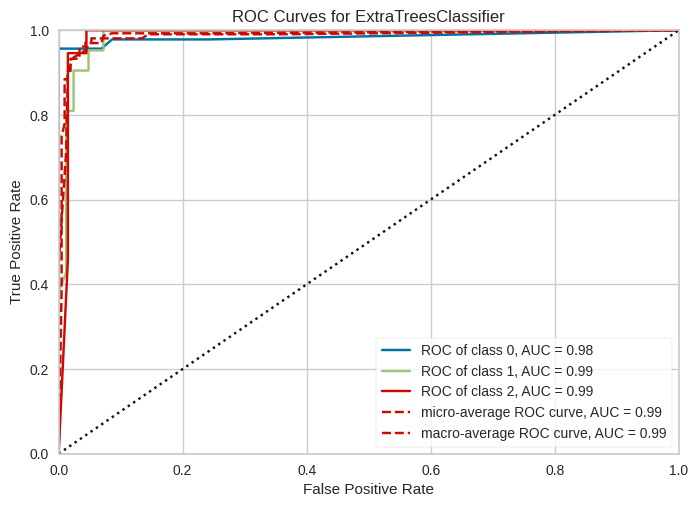

In [7]:
plot_model(best, plot = 'auc')

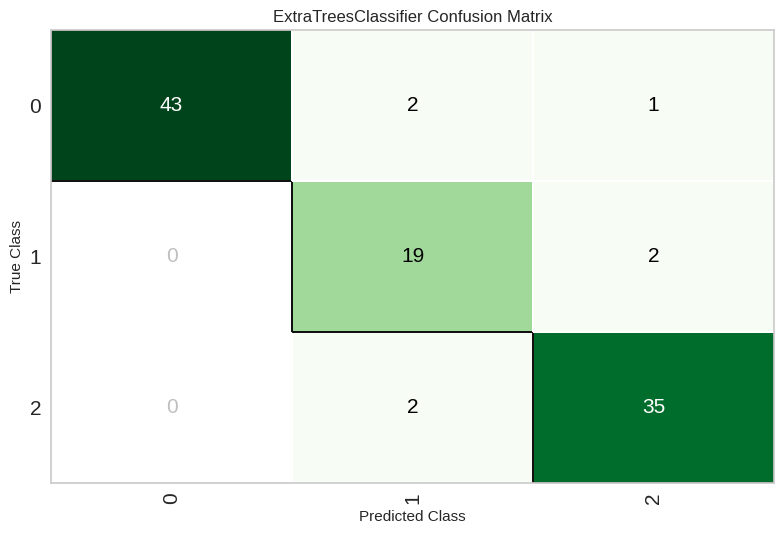

In [8]:
plot_model(best, plot = 'confusion_matrix')

In [9]:
predict_model(best)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9327,0.9860,0.9327,0.9368,0.9338,0.8952,0.8962


,bill_length_mm,bill_depth_mm,species,prediction_label,prediction_score
166,45.900002,17.100000,Chinstrap,Chinstrap,0.73
96,38.099998,18.600000,Adelie,Adelie,1.00
157,45.200001,17.799999,Chinstrap,Chinstrap,0.61
259,48.700001,15.700000,Gentoo,Gentoo,1.00
210,50.200001,18.799999,Chinstrap,Chinstrap,0.94
...,...,...,...,...,...
278,43.200001,14.500000,Gentoo,Gentoo,0.92
32,39.500000,17.799999,Adelie,Adelie,0.99
185,51.000000,18.799999,Chinstrap,Chinstrap,0.93
149,37.799999,18.100000,Adelie,Adelie,1.00


In [10]:
predictions = predict_model(best, data=df)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9797,0.9971,0.9797,0.9801,0.9798,0.9681,0.9682


,bill_length_mm,bill_depth_mm,species,prediction_label,prediction_score
0,39.099998,18.700001,Adelie,Adelie,1.0
1,39.500000,17.400000,Adelie,Adelie,1.0
2,40.299999,18.000000,Adelie,Adelie,1.0
3,NaN,NaN,Adelie,Gentoo,1.0
4,36.700001,19.299999,Adelie,Adelie,1.0


In [11]:
predictions = predict_model(best, data=df, raw_score=True)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.9797,0.9971,0.9797,0.9801,0.9798,0.9681,0.9682


,bill_length_mm,bill_depth_mm,species,prediction_label,prediction_score_Adelie,prediction_score_Chinstrap,prediction_score_Gentoo
0,39.099998,18.700001,Adelie,Adelie,1.0,0.0,0.0
1,39.500000,17.400000,Adelie,Adelie,1.0,0.0,0.0
2,40.299999,18.000000,Adelie,Adelie,1.0,0.0,0.0
3,NaN,NaN,Adelie,Gentoo,0.0,0.0,1.0
4,36.700001,19.299999,Adelie,Adelie,1.0,0.0,0.0


In [15]:
import pandas as pd
import seaborn as sns
from pycaret.classification import *

# 1. Get the data (using seaborn since it's reliable)
penguins = sns.load_dataset('penguins')

# 2. Define your features and targets
# We include both targets here so we can clean them at once
df = penguins[['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'species']]

# 3. CLEANING: This is the most important step!
# Drop rows where EITHER sex or species is missing
df_clean = df.dropna(subset=['sex', 'species'])

# 4. Verification (This won't throw a NameError now)
print("Missing values per column:")
print(df_clean.isnull().sum())

# 5. Run Setup for your first target (Species)
s1 = setup(data = df_clean, target = 'species', session_id = 678, ignore_features = ['sex'])

Missing values per column:
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
species              0
dtype: int64


,Description,Value
0,Session id,678
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(333, 7)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Ignore features,1
9,Numeric features,4


In [19]:
import seaborn as sns
import pandas as pd
from pycaret.classification import *

# 1. Load the raw data
penguins = sns.load_dataset('penguins')

# 2. Define the columns you want (Features + Both Targets)
# We use 'thrid' as your variable name from the previous step
thrid = penguins[['bill_length_mm', 'bill_depth_mm', 'island',
                  'body_mass_g', 'flipper_length_mm', 'sex', 'species']]

# 3. Clean: Drop rows missing EITHER target
# This ensures your 'sex' and 'species' columns are ready for modeling
thrid_cleaned = thrid.dropna(subset=['sex', 'species'])

# 4. Verification: check that the NameError is gone and data is clean
print(f"Data ready! Total rows: {len(thrid_cleaned)}")
print(thrid_cleaned.isnull().sum())

# 5. Setup for Target 1: Species (Ignoring 'sex' so it doesn't "cheat")
s_species = setup(data = thrid_cleaned, target = 'species',
                  ignore_features = ['sex'], session_id = 678)

Data ready! Total rows: 333
bill_length_mm       0
bill_depth_mm        0
island               0
body_mass_g          0
flipper_length_mm    0
sex                  0
species              0
dtype: int64


,Description,Value
0,Session id,678
1,Target,species
2,Target type,Multiclass
3,Target mapping,"Adelie: 0, Chinstrap: 1, Gentoo: 2"
4,Original data shape,"(333, 7)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Ignore features,1
9,Numeric features,4


In [20]:
best2 = compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.9958,0.0000,0.9958,0.9962,0.9957,0.9934,0.9937,0.0610
lda,Linear Discriminant Analysis,0.9958,0.0000,0.9958,0.9962,0.9957,0.9934,0.9937,0.0580
lr,Logistic Regression,0.9957,0.0000,0.9957,0.9960,0.9955,0.9931,0.9934,1.1120
rf,Random Forest Classifier,0.9957,0.9996,0.9957,0.9965,0.9958,0.9931,0.9934,0.3540
et,Extra Trees Classifier,0.9915,1.0000,0.9915,0.9927,0.9915,0.9866,0.9871,0.1830
xgboost,Extreme Gradient Boosting,0.9915,0.9996,0.9915,0.9927,0.9915,0.9866,0.9871,0.1830
gbc,Gradient Boosting Classifier,0.9913,0.0000,0.9913,0.9927,0.9915,0.9862,0.9868,0.3550
lightgbm,Light Gradient Boosting Machine,0.9913,1.0000,0.9913,0.9930,0.9916,0.9863,0.9869,0.2730
dt,Decision Tree Classifier,0.9828,0.9872,0.9828,0.9852,0.9828,0.9731,0.9742,0.0630
ada,Ada Boost Classifier,0.8533,0.0000,0.8533,0.8318,0.8159,0.7593,0.7899,0.1400


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [21]:
print(best2)

RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=678, solver='auto',
                tol=0.0001)


In [22]:
evaluate_model(best2)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

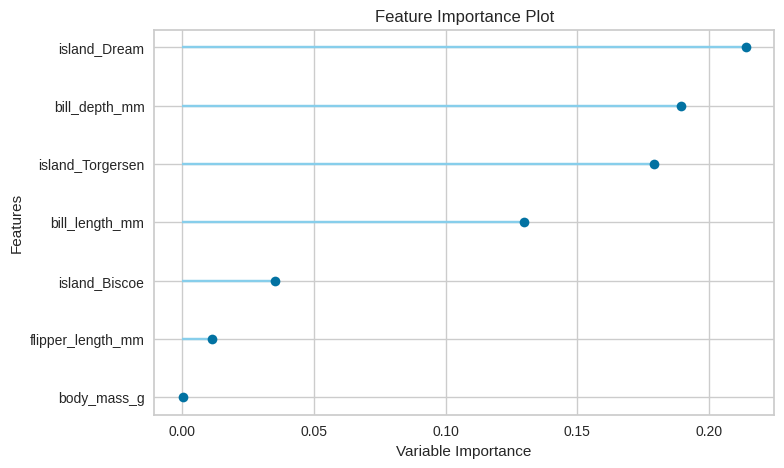

In [23]:
plot_model(best2, plot = 'feature')

In [24]:
predict_model(best2)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9900,0,0.9900,0.9902,0.9899,0.9842,0.9844


,bill_length_mm,bill_depth_mm,island,body_mass_g,flipper_length_mm,species,prediction_label
56,39.000000,17.500000,Biscoe,3550.0,186.0,Adelie,Adelie
253,59.599998,17.000000,Biscoe,6050.0,230.0,Gentoo,Gentoo
127,41.500000,18.299999,Torgersen,4300.0,195.0,Adelie,Adelie
150,36.000000,17.100000,Dream,3700.0,187.0,Adelie,Adelie
48,36.000000,17.900000,Dream,3450.0,190.0,Adelie,Adelie
...,...,...,...,...,...,...,...
170,46.400002,18.600000,Dream,3450.0,190.0,Chinstrap,Chinstrap
180,46.400002,17.799999,Dream,3700.0,191.0,Chinstrap,Chinstrap
285,49.799999,16.799999,Biscoe,5700.0,230.0,Gentoo,Gentoo
316,49.400002,15.800000,Biscoe,4925.0,216.0,Gentoo,Gentoo


In [26]:
predictions = predict_model(best2, data=thrid_cleaned)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9940,0,0.9940,0.9941,0.9940,0.9906,0.9906


,bill_length_mm,bill_depth_mm,island,body_mass_g,flipper_length_mm,sex,species,prediction_label
0,39.099998,18.700001,Torgersen,3750.0,181.0,Male,Adelie,Adelie
1,39.500000,17.400000,Torgersen,3800.0,186.0,Female,Adelie,Adelie
2,40.299999,18.000000,Torgersen,3250.0,195.0,Female,Adelie,Adelie
4,36.700001,19.299999,Torgersen,3450.0,193.0,Female,Adelie,Adelie
5,39.299999,20.600000,Torgersen,3650.0,190.0,Male,Adelie,Adelie


In [27]:
predictions = predict_model(best2, data=thrid_cleaned)
predictions.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Ridge Classifier,0.9940,0,0.9940,0.9941,0.9940,0.9906,0.9906


,bill_length_mm,bill_depth_mm,island,body_mass_g,flipper_length_mm,sex,species,prediction_label
0,39.099998,18.700001,Torgersen,3750.0,181.0,Male,Adelie,Adelie
1,39.500000,17.400000,Torgersen,3800.0,186.0,Female,Adelie,Adelie
2,40.299999,18.000000,Torgersen,3250.0,195.0,Female,Adelie,Adelie
4,36.700001,19.299999,Torgersen,3450.0,193.0,Female,Adelie,Adelie
5,39.299999,20.600000,Torgersen,3650.0,190.0,Male,Adelie,Adelie


In [28]:
from pycaret.classification import *
thrid = penguins [['bill_length_mm','bill_depth_mm','island', 'body_mass_g', 'flipper_length_mm', 'sex','species' ]]
# Create a combined target column
thrid['combined_target'] = thrid['species'] + "_" + thrid['sex']

# Drop the individual columns to avoid leakage
df_combined = thrid.drop(['species', 'sex'], axis=1).dropna()

# Setup with the new single target
s = setup(df_combined, target='combined_target', session_id=678)
best_model = compare_models()


,Description,Value
0,Session id,678
1,Target,combined_target
2,Target type,Multiclass
3,Target mapping,"Adelie_Female: 0, Adelie_Male: 1, Chinstrap_Female: 2, Chinstrap_Male: 3, Gentoo_Female: 4, Gentoo_Male: 5"
4,Original data shape,"(333, 6)"
5,Transformed data shape,"(333, 8)"
6,Transformed train set shape,"(233, 8)"
7,Transformed test set shape,"(100, 8)"
8,Numeric features,4
9,Categorical features,1


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9013,0.9886,0.9013,0.9088,0.8962,0.8796,0.8839,0.5830
xgboost,Extreme Gradient Boosting,0.9009,0.9851,0.9009,0.9109,0.8955,0.8788,0.8827,0.2250
gbc,Gradient Boosting Classifier,0.8926,0.0000,0.8926,0.9108,0.8884,0.8688,0.8727,0.6220
rf,Random Forest Classifier,0.8924,0.9920,0.8924,0.9063,0.8854,0.8688,0.8746,0.2290
lda,Linear Discriminant Analysis,0.8924,0.0000,0.8924,0.9109,0.8898,0.8685,0.8728,0.0580
et,Extra Trees Classifier,0.8839,0.9925,0.8839,0.9017,0.8757,0.8584,0.8657,0.1880
ridge,Ridge Classifier,0.8458,0.0000,0.8458,0.8502,0.8297,0.8111,0.8202,0.0610
dt,Decision Tree Classifier,0.8324,0.8986,0.8324,0.8385,0.8245,0.7953,0.8011,0.0560
lr,Logistic Regression,0.7774,0.0000,0.7774,0.7924,0.7691,0.7279,0.7343,1.1530
nb,Naive Bayes,0.7545,0.9701,0.7545,0.8432,0.7519,0.7086,0.7310,0.0600


Processing:   0%|          | 0/65 [00:00<?, ?it/s]

In [29]:
print(best_model)

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=678, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [30]:
evaluate_model(best_model)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

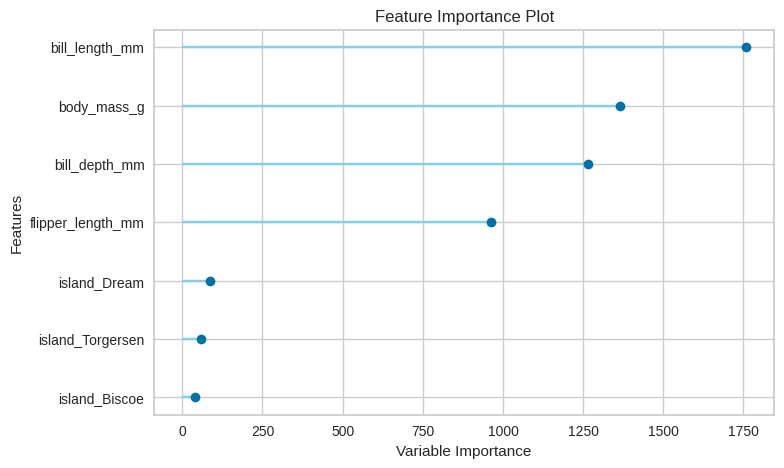

In [31]:
plot_model(best_model, plot = 'feature')

In [32]:
predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9100,0.9949,0.9100,0.9139,0.9095,0.8899,0.8909


,bill_length_mm,bill_depth_mm,island,body_mass_g,flipper_length_mm,combined_target,prediction_label,prediction_score
121,37.700001,19.799999,Torgersen,3500.0,198.0,Adelie_Male,Adelie_Female,0.8494
239,48.700001,15.100000,Biscoe,5350.0,222.0,Gentoo_Male,Gentoo_Male,1.0000
18,34.400002,18.400000,Torgersen,3325.0,184.0,Adelie_Female,Adelie_Female,1.0000
78,36.200001,16.100000,Torgersen,3550.0,187.0,Adelie_Female,Adelie_Female,1.0000
115,42.700001,18.299999,Biscoe,4075.0,196.0,Adelie_Male,Adelie_Male,1.0000
...,...,...,...,...,...,...,...,...
208,45.200001,16.600000,Dream,3250.0,191.0,Chinstrap_Female,Chinstrap_Female,0.9999
156,52.700001,19.799999,Dream,3725.0,197.0,Chinstrap_Male,Chinstrap_Male,0.9999
306,43.400002,14.400000,Biscoe,4600.0,218.0,Gentoo_Female,Gentoo_Female,1.0000
311,52.200001,17.100000,Biscoe,5400.0,228.0,Gentoo_Male,Gentoo_Male,1.0000


In [35]:
predictions = predict_model(best_model, data=df_combined)
predictions.head()


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9730,0.9995,0.9730,0.9734,0.9729,0.9670,0.9671


,bill_length_mm,bill_depth_mm,island,body_mass_g,flipper_length_mm,combined_target,prediction_label,prediction_score
0,39.099998,18.700001,Torgersen,3750.0,181.0,Adelie_Male,Adelie_Male,0.9956
1,39.500000,17.400000,Torgersen,3800.0,186.0,Adelie_Female,Adelie_Female,0.9963
2,40.299999,18.000000,Torgersen,3250.0,195.0,Adelie_Female,Adelie_Female,0.9999
4,36.700001,19.299999,Torgersen,3450.0,193.0,Adelie_Female,Adelie_Female,0.9992
5,39.299999,20.600000,Torgersen,3650.0,190.0,Adelie_Male,Adelie_Male,0.9933
